<div align='center'>
  <p><strong><a href='https://br.linkedin.com/in/isaac-maciel' target='_blank'>Autor: Isaac Maciel - RM 98222 - 2TIAOA - FIAP AI 2026</a></strong></p>
  <img src='https://github.com/IM-NOT-AI/IM-not-AI/assets/113378671/0a6e0c0f-fcdf-4ccc-af00-63e30836d180' alt='isaac_banner' width='480'/>

# Cardio-Edge-AI · FIAP AI 2026 · Fase 2 · IR ALÉM 2


## NB8 - MLP ECG Heartbeat Classifier

Dataset: MIT-BIH Arrhythmia (Kaggle - shayanfazeli/heartbeat) Objetivo: classificar batimentos cardiacos em 5 classes de arritmia Entregavel: Ir Alem 2 - Diagnostico visual em cardiologia com rede neural

## Classificador de Arritmias Cardiacas com MLP

**Dataset:** MIT-BIH Arrhythmia - Kaggle (shayanfazeli/heartbeat)

**Objetivo:** classificar batimentos ECG em 5 categorias de ritmo cardiaco

**Arquitetura:** MLP (Perceptron Multicamadas) via Keras/TensorFlow

**Deployment alvo:** TFLite INT8 para Raspberry Pi 5 + Coral TPU

<br>

> Referencia do dataset: cada linha representa um batimento cardiaco segmentado e normalizado (187 pontos de sinal a 360 Hz + 1 coluna de label).

## Nota sobre a abordagem deste notebook

Na primeira experimentacao, optei por trabalhar diretamente com os sinais tabulares do
dataset shayanfazeli/heartbeat - 187 pontos numericos por batimento - em vez de converter
cada batimento em uma imagem 2D. A justificativa tecnica era que uma MLP sobre series
temporais tabuladas e mais eficiente (menor custo computacional, sem perda de informacao
por quantizacao de pixel) e mais adequada para deploy em edge com TFLite INT8.

Apos revisar os criterios de avaliacao do enunciado ("pre-processamento de imagens",
"diagnostico visual", "exemplos de imagens no repositorio"), identifiquei dois ajustes
necessarios para alinhamento completo:

1. Exportar representacoes visuais dos batimentos ECG como imagens PNG por classe, os sinais plotados sao a "imagem de ECG" no contexto deste dataset de sinais.

2. Incluir avaliacao binaria (Normal vs. Anormal) alem da multiclasse, atendendo, ao requisito de "classificacao binaria" do enunciado.

3. Corrigir o split de validacao para estratificado, eliminando o bug de convergencia, causado pelo validation_split sequencial em dados ordenados por classe.

Essas correcoes nao invalidam a primeira experimentacao - elas a complementam.

### Imports e Configuracão

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print('TensorFlow:', tf.__version__)
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw', 'heartbeat')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
LOGS_DIR = os.path.join(BASE_DIR, 'logs')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, 'mitbih_train.csv')
TEST_PATH = os.path.join(DATA_DIR, 'mitbih_test.csv')

def rel(path):
    try:
        return os.path.relpath(path, BASE_DIR)
    except ValueError:
        return path

print()
print('DATA_DIR:', rel(DATA_DIR))
print('MODELS_DIR:', rel(MODELS_DIR))
print('LOGS_DIR:', rel(LOGS_DIR))
print()
print('mitbih_train.csv existe:', os.path.exists(TRAIN_PATH))
print('mitbih_test.csv  existe:', os.path.exists(TEST_PATH))

TensorFlow: 2.18.0
NumPy: 1.26.4
Pandas: 3.0.0

DATA_DIR: data\raw\heartbeat
MODELS_DIR: models
LOGS_DIR: logs

mitbih_train.csv existe: True
mitbih_test.csv  existe: True


### Carga dos Dados

## 1. Carga dos Dados

> Os arquivos CSV nao possuem cabecalho (header=None).
>
> O dataset contem batimentos ja segmentados e normalizados globalmente entre 0 e 1.
>
>Primeiro passo: carregar e confirmar o shape antes de qualquer analise.

### Carga e Shape

In [2]:
train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df = pd.read_csv(TEST_PATH, header=None)

print('Shape treino:', train_df.shape)
print('Shape teste:', test_df.shape)

Shape treino: (87554, 188)
Shape teste: (21892, 188)


### Explorando as Colunas

> O dataset nao tem nomes de colunas. Precisamos entender a semantica pelo indice: colunas 0 a 186 sao os pontos do sinal ECG, coluna 187 e o label.

### Inspeção das Colunas

In [3]:
print('Total de colunas:', len(train_df.columns))
print()
print('Primeiras 5 colunas (indices):', list(train_df.columns[:5]))
print('Ultimas 5 colunas (indices): ', list(train_df.columns[-5:]))
print()
print('Tipos de dado:')
print(train_df.dtypes.value_counts())

Total de colunas: 188

Primeiras 5 colunas (indices): [0, 1, 2, 3, 4]
Ultimas 5 colunas (indices):  [183, 184, 185, 186, 187]

Tipos de dado:
float64    188
Name: count, dtype: int64


### Verificação de Integridade

> Antes de explorar, confirmar que nao ha dados faltantes e que o range do sinal esta dentro do esperado (0 a 1).

### NaN e Range

In [4]:
print('=== Valores Ausentes ===')
print('NaN no treino:', train_df.isnull().sum().sum())
print('NaN no teste:', test_df.isnull().sum().sum())

print()
print('=== Range do Sinal (colunas 0-186) ===')
signal_vals = train_df.iloc[:, :187].values
print('Minimo global:', signal_vals.min())
print('Maximo global:', signal_vals.max())
print('Media global:', round(signal_vals.mean(), 4))
print('Std global:', round(signal_vals.std(), 4))

=== Valores Ausentes ===
NaN no treino: 0
NaN no teste: 0

=== Range do Sinal (colunas 0-186) ===
Minimo global: 0.0
Maximo global: 1.0
Media global: 0.1743
Std global: 0.2263


### Estatísticas Descritivas das Features

> Vamos olhar describe() nas colunas extremas do sinal para entender como o dataset foi construido - onde comeca o sinal e onde termina.

### Describe por Região do Sinal

In [5]:
print('=== Coluna 0 - inicio do sinal ===')
print(train_df[0].describe())

print()
print('=== Coluna 93 - meio do sinal (pico QRS aprox) ===')
print(train_df[93].describe())

print()
print('=== Coluna 186 - final do sinal ===')
print(train_df[186].describe())

=== Coluna 0 - inicio do sinal ===
count    87554.000000
mean         0.890360
std          0.240909
min          0.000000
25%          0.921922
50%          0.991342
75%          1.000000
max          1.000000
Name: 0, dtype: float64

=== Coluna 93 - meio do sinal (pico QRS aprox) ===
count    87554.000000
mean         0.207332
std          0.230910
min          0.000000
25%          0.000000
50%          0.129489
75%          0.320596
max          1.000000
Name: 93, dtype: float64

=== Coluna 186 - final do sinal ===
count    87554.000000
mean         0.002807
std          0.031924
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: 186, dtype: float64


## Distribuição das Classes - Label

> A coluna 187 e o label de classificacao. Vamos entender quais classes existem e o desbalanceamento entre elas.

### Análise do Label

In [6]:
print('=== Coluna 187 - Label ===')
print('Tipo:', train_df[187].dtype)
print('Valores unicos:', sorted(train_df[187].unique()))
print()

label_map = {
    0.0: 'Normal (N)',
    1.0: 'Supraventricular (S)',
    2.0: 'Ventricular (V)',
    3.0: 'Fusion (F)',
    4.0: 'Desconhecido (Q)'
}

print('=== Distribuicao - Treino ===')
vc_train = train_df[187].value_counts().sort_index()
for cls, count in vc_train.items():
    pct = count / len(train_df) * 100
    print(f'  Classe {int(cls)} - {label_map[cls]:<25}: {count:6d} ({pct:.1f}%)')

print()
print('=== Distribuicao - Teste ===')
vc_test = test_df[187].value_counts().sort_index()
for cls, count in vc_test.items():
    pct = count / len(test_df) * 100
    print(f'- Classe {int(cls)} - {label_map[cls]:<25}: {count:6d} ({pct:.1f}%)')

=== Coluna 187 - Label ===
Tipo: float64
Valores unicos: [0.0, 1.0, 2.0, 3.0, 4.0]

=== Distribuicao - Treino ===
  Classe 0 - Normal (N)               :  72471 (82.8%)
  Classe 1 - Supraventricular (S)     :   2223 (2.5%)
  Classe 2 - Ventricular (V)          :   5788 (6.6%)
  Classe 3 - Fusion (F)               :    641 (0.7%)
  Classe 4 - Desconhecido (Q)         :   6431 (7.3%)

=== Distribuicao - Teste ===
- Classe 0 - Normal (N)               :  18118 (82.8%)
- Classe 1 - Supraventricular (S)     :    556 (2.5%)
- Classe 2 - Ventricular (V)          :   1448 (6.6%)
- Classe 3 - Fusion (F)               :    162 (0.7%)
- Classe 4 - Desconhecido (Q)         :   1608 (7.3%)


### Gráfico de Distribuição das Classes

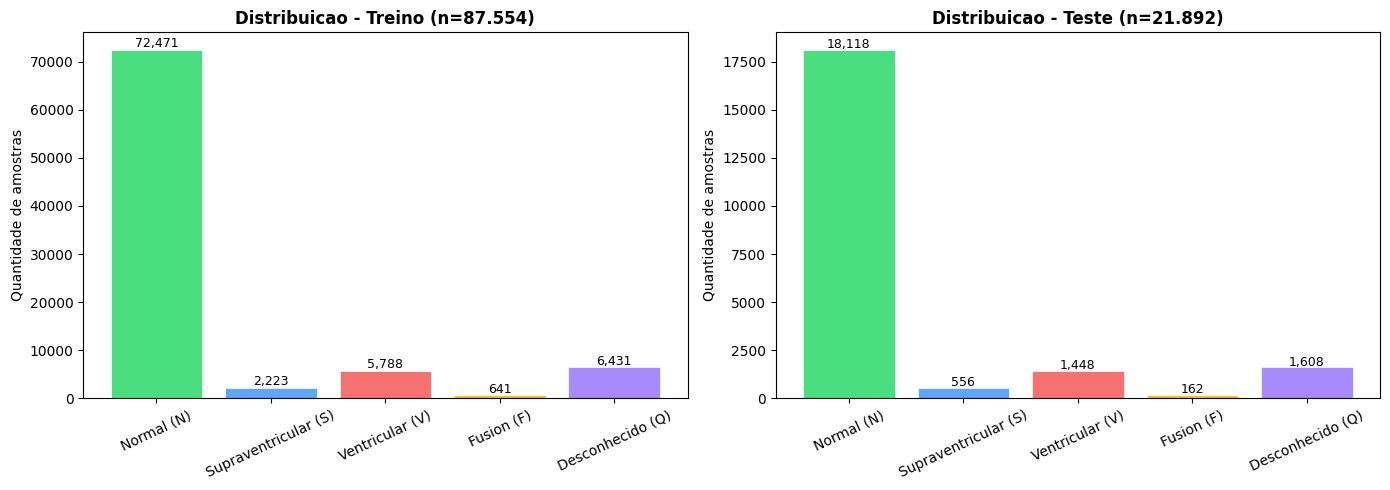

Grafico salvo em logs/class_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = [label_map[k] for k in sorted(label_map.keys())]
counts_train = [vc_train.get(k, 0) for k in sorted(label_map.keys())]
counts_test = [vc_test.get(k, 0)  for k in sorted(label_map.keys())]
colors = ['#4ade80', '#60a5fa', '#f87171', '#fbbf24', '#a78bfa']

# Treino
axes[0].bar(classes, counts_train, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribuicao - Treino (n=87.554)', fontweight='bold')
axes[0].set_ylabel('Quantidade de amostras')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(counts_train):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Teste
axes[1].bar(classes, counts_test, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribuicao - Teste (n=21.892)', fontweight='bold')
axes[1].set_ylabel('Quantidade de amostras')
axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(counts_test):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'class_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Grafico salvo em logs/class_distribution.png')

## Visualização dos Sinais por Classe

> Vamos plotar um batimento de cada classe para ver a morfologia e entender o que o modelo precisara aprender a diferenciar.

### Plot de um Batimento por Classe

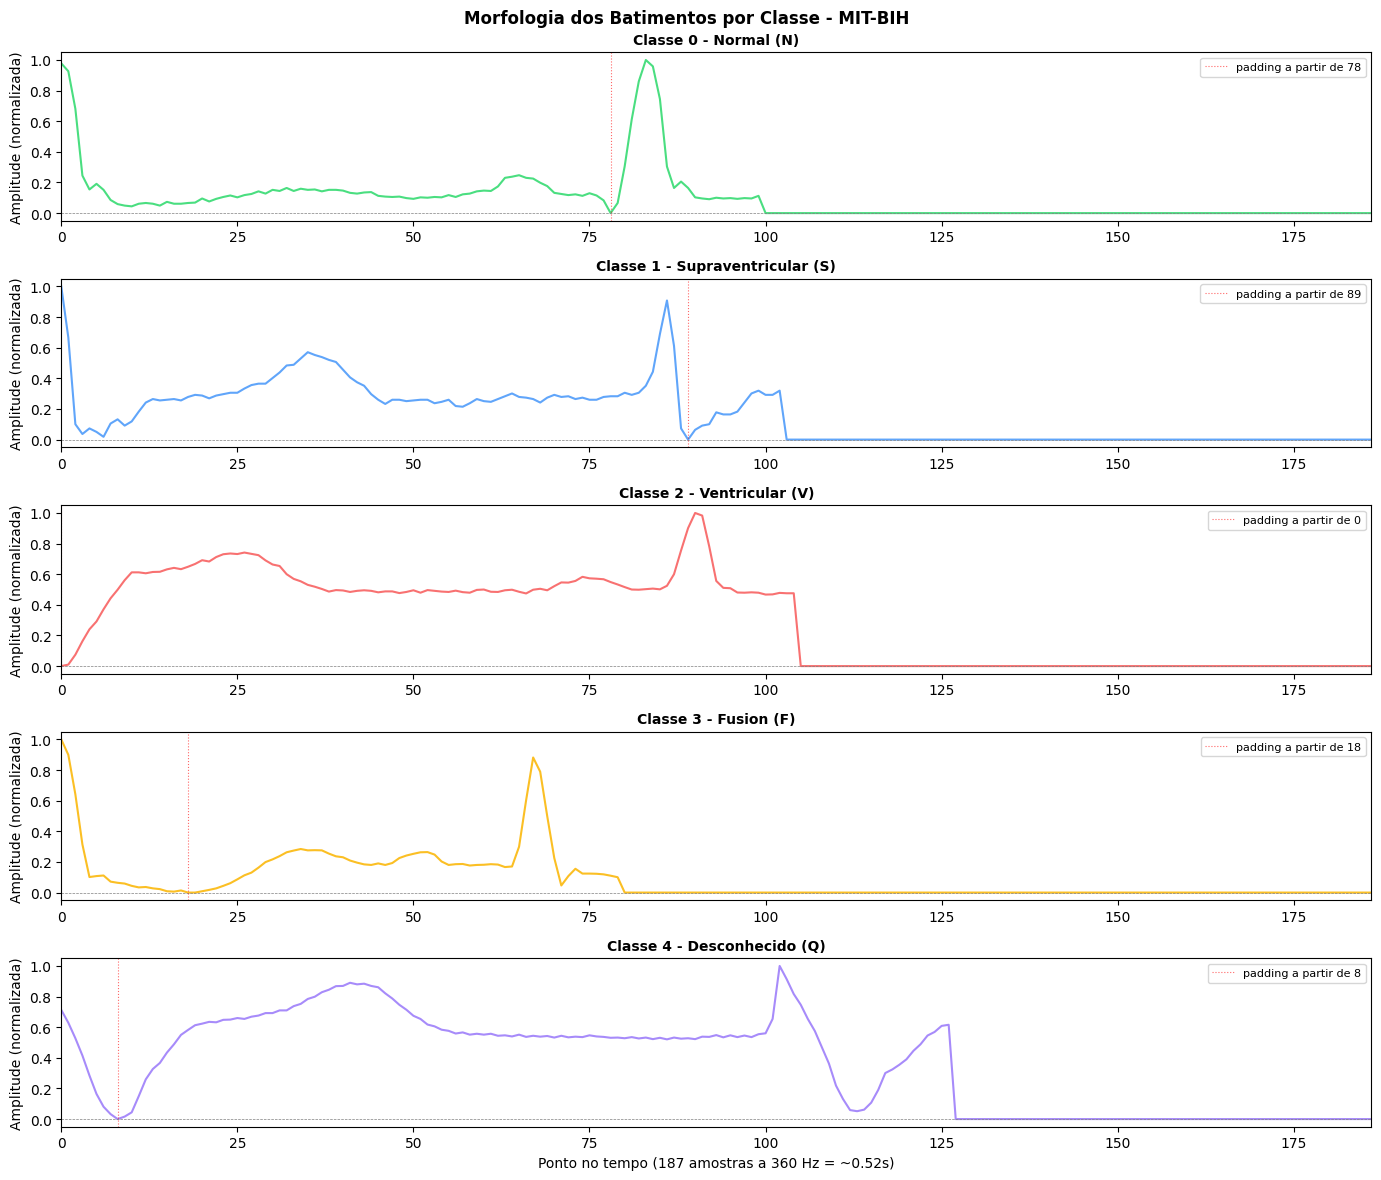

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12))
x_axis = np.arange(187)

for cls in range(5):
    sample = train_df[train_df[187] == float(cls)].iloc[0, :187].values
    ax = axes[cls]
    ax.plot(x_axis, sample, color=colors[cls], linewidth=1.5)
    ax.set_title(f'Classe {cls} - {label_map[float(cls)]}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Amplitude (normalizada)')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlim(0, 186)
    # Marcar onde o padding comeca (valores zerados)
    padding_start = np.where(sample == 0.0)[0]
    if len(padding_start) > 0:
        ax.axvline(padding_start[0], color='red', linewidth=0.8,
                   linestyle=':', alpha=0.6, label=f'padding a partir de {padding_start[0]}')
        ax.legend(fontsize=8)

axes[-1].set_xlabel('Ponto no tempo (187 amostras a 360 Hz = ~0.52s)')
plt.suptitle('Morfologia dos Batimentos por Classe - MIT-BIH', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'signal_morphology.png'), dpi=120, bbox_inches='tight')
plt.show()

## Exportação de Imagens ECG por Classe

O enunciado do Ir Alem 2 pede "exemplos de imagens" no repositorio GitHub e "pre-processamento de imagens de ECG". O dataset shayanfazeli/heartbeat NAO e um dataset de imagens, e uma colecao de sinais tabulados em CSV.


A representacao visual equivalente e o plot do sinal de cada batimento: cada classe de arritmia tem uma morfologia caracteristica identificavel visualmente (pico QRS largo em Ventricular, ausencia de onda P em Fibrilacao, etc.). Esses plots sao os "exemplos de imagens de ECG" que serao incluidos no repositorio.


Exportamos 3 exemplos por classe em alta resolucao para o diretorio logs/ecg_samples/ - esses arquivos PNG serao commitados no GitHub.

In [9]:
ECG_SAMPLES_DIR = os.path.join(LOGS_DIR, 'ecg_samples')
os.makedirs(ECG_SAMPLES_DIR, exist_ok=True)

N_EXEMPLOS = 3  # exemplos por classe

for cls in range(5):
    subset_idx = train_df[train_df[187] == float(cls)].index
    nome_classe = label_map[float(cls)].replace(' ', '_').replace('(', '').replace(')', '')

    for i in range(min(N_EXEMPLOS, len(subset_idx))):
        sinal = train_df.loc[subset_idx[i], :186].values

        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(np.arange(187), sinal, color=colors[cls], linewidth=1.8)
        ax.set_title(f'ECG - Classe {cls}: {label_map[float(cls)]}  (amostra {i+1})',
                     fontweight='bold', fontsize=11)
        ax.set_xlabel('Ponto no tempo (187 amostras a 360 Hz = ~0.52s)')
        ax.set_ylabel('Amplitude normalizada [0, 1]')
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlim(0, 186)
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
        ax.grid(alpha=0.2)

        fname = f'ecg_classe{cls}_{nome_classe}_ex{i+1}.png'
        fpath = os.path.join(ECG_SAMPLES_DIR, fname)
        plt.savefig(fpath, dpi=150, bbox_inches='tight')
        plt.close()

print(f'Imagens ECG exportadas em: {rel(ECG_SAMPLES_DIR)}')
print(f'Total: {N_EXEMPLOS * 5} arquivos PNG  ({N_EXEMPLOS} por classe x 5 classes)')
print()
for cls in range(5):
    nome = label_map[float(cls)].replace(' ', '_').replace('(', '').replace(')', '')
    print(f'- Classe {cls} ({label_map[float(cls)]}):')
    for i in range(1, N_EXEMPLOS + 1):
        print(f'-  ecg_classe{cls}_{nome}_ex{i}.png')

Imagens ECG exportadas em: logs\ecg_samples
Total: 15 arquivos PNG  (3 por classe x 5 classes)

- Classe 0 (Normal (N)):
-  ecg_classe0_Normal_N_ex1.png
-  ecg_classe0_Normal_N_ex2.png
-  ecg_classe0_Normal_N_ex3.png
- Classe 1 (Supraventricular (S)):
-  ecg_classe1_Supraventricular_S_ex1.png
-  ecg_classe1_Supraventricular_S_ex2.png
-  ecg_classe1_Supraventricular_S_ex3.png
- Classe 2 (Ventricular (V)):
-  ecg_classe2_Ventricular_V_ex1.png
-  ecg_classe2_Ventricular_V_ex2.png
-  ecg_classe2_Ventricular_V_ex3.png
- Classe 3 (Fusion (F)):
-  ecg_classe3_Fusion_F_ex1.png
-  ecg_classe3_Fusion_F_ex2.png
-  ecg_classe3_Fusion_F_ex3.png
- Classe 4 (Desconhecido (Q)):
-  ecg_classe4_Desconhecido_Q_ex1.png
-  ecg_classe4_Desconhecido_Q_ex2.png
-  ecg_classe4_Desconhecido_Q_ex3.png


### Sinal Médio por Classe

> A media de todos os batimentos de uma classe mostra o "formato tipico".
>
> O envelope (media +/- desvio padrao) mostra a variabilidade intra-classe.

### Envelope do Sinal por Classe

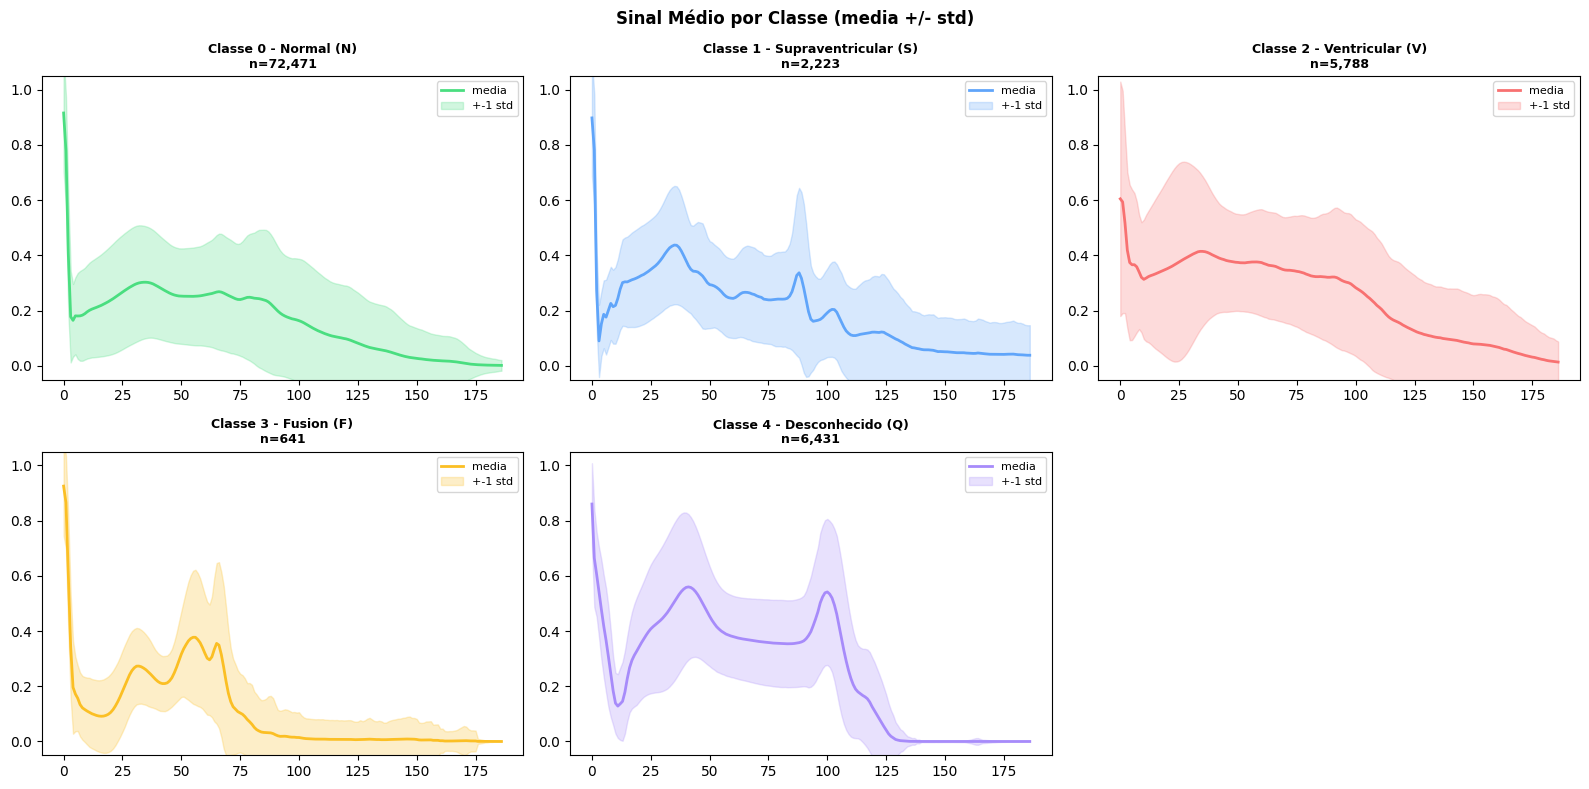

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for cls in range(5):
    subset = train_df[train_df[187] == float(cls)].iloc[:, :187].values
    mean_sig = subset.mean(axis=0)
    std_sig  = subset.std(axis=0)
    ax = axes[cls]
    ax.plot(x_axis, mean_sig, color=colors[cls], linewidth=2, label='media')
    ax.fill_between(x_axis,
                    mean_sig - std_sig,
                    mean_sig + std_sig,
                    alpha=0.25, color=colors[cls], label='+-1 std')
    ax.set_title(f'Classe {cls} - {label_map[float(cls)]}\nn={len(subset):,}',
                 fontweight='bold', fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Sinal Médio por Classe (media +/- std)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'signal_mean_envelope.png'), dpi=120, bbox_inches='tight')
plt.show()

## Pré-processamento

Duas decisoes de normalizacao:

1. O dataset JA esta globalmente normalizado [0, 1] na criacao.

2. Vamos aplicar normalizacao por amostra (Z-score) ADICIONAL para
   enfatizar a MORFOLOGIA de cada batimento, ignorando amplitude absoluta.

> Justificativa: dois batimentos Normais podem ter amplitudes diferentes (pacientes diferentes, eletrodos diferentes), mas a FORMA e similar. A normalizacao por amostra faz o modelo focar em forma, nao em escala.

### Separação X/y e Normalização

In [11]:
# Separar features e labels
X_train = train_df.iloc[:, :187].values.astype(np.float32)
y_train = train_df.iloc[:, 187].values.astype(np.int32)

X_test = test_df.iloc[:, :187].values.astype(np.float32)
y_test = test_df.iloc[:, 187].values.astype(np.int32)

print('X_train shape:', X_train.shape, '| dtype:', X_train.dtype)
print('y_train shape:', y_train.shape, '| dtype:', y_train.dtype)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)
print()
print('Labels únicos em y_train:', np.unique(y_train))
print('Labels únicos em y_test: ', np.unique(y_test))

X_train shape: (87554, 187) | dtype: float32
y_train shape: (87554,) | dtype: int32
X_test shape: (21892, 187)
y_test shape: (21892,)

Labels únicos em y_train: [0 1 2 3 4]
Labels únicos em y_test:  [0 1 2 3 4]


### Normalização por Amostra

In [12]:
# Normalizacao por amostra (Z-score) - enfatiza morfologia
X_train_mean = X_train.mean(axis=1, keepdims=True)
X_train_std = X_train.std(axis=1, keepdims=True) + 1e-8
X_train_norm = (X_train - X_train_mean) / X_train_std

X_test_mean = X_test.mean(axis=1, keepdims=True)
X_test_std = X_test.std(axis=1, keepdims=True) + 1e-8
X_test_norm = (X_test - X_test_mean) / X_test_std

print('Antes da normalizacao - X_train:')
print(f'- range: [{X_train.min():.4f}, {X_train.max():.4f}]')
print(f'- média: {X_train.mean():.4f} | std: {X_train.std():.4f}')

print()
print('Apos normalizacao por amostra - X_train_norm:')
print(f'- range: [{X_train_norm.min():.4f}, {X_train_norm.max():.4f}]')
print(f'- média por amostra (média das medias): {X_train_norm.mean(axis=1).mean():.6f}')
print(f'- std por amostra (média dos stds): {X_train_norm.std(axis=1).mean():.4f}')

Antes da normalizacao - X_train:
- range: [0.0000, 1.0000]
- média: 0.1743 | std: 0.2263

Apos normalizacao por amostra - X_train_norm:
- range: [-6.0529, 12.7239]
- média por amostra (média das medias): 0.000000
- std por amostra (média dos stds): 1.0000


## Pesos de Classe para Desbalanceamento

> Com 82.8% dos dados sendo Normal, sem intervencao o modelo aprenderia a sempre prever Normal e atingir 82.8% de acuracia sem aprender nada util.
>
> Solucao: class_weight='balanced' - penaliza proporcionalmente os erros nas classes com menos amostras, sem precisar de oversampling ou SMOTE.

### Cálculo dos Pesos

In [13]:
cw_values = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(cw_values))

print('Pesos por classe:')
for cls, weight in class_weight.items():
    n = (y_train == cls).sum()
    print(f'- Classe {cls} - {label_map[float(cls)]:<25}: {weight:.4f}  (n={n:,})')

Pesos por classe:
- Classe 0 - Normal (N)               : 0.2416  (n=72,471)
- Classe 1 - Supraventricular (S)     : 7.8771  (n=2,223)
- Classe 2 - Ventricular (V)          : 3.0254  (n=5,788)
- Classe 3 - Fusion (F)               : 27.3179  (n=641)
- Classe 4 - Desconhecido (Q)         : 2.7229  (n=6,431)


## Arquitetura da Rede Neural (MLP)

> 187 features tabulares (pontos do sinal) -> 5 classes de saida.

>MLP e adequado aqui: os dados sao series temporais tabuladas,

>sem estrutura espacial 2D que justificaria CNN.

<br>

> A rede decai 256 -> 128 -> 64 -> 5 (funil de extracao de features).

> BatchNormalization apos cada camada: estabiliza gradientes.

>Dropout decrescente: regularizacao mais forte nas camadas iniciais.

### Definição e Summary do Modelo

In [14]:
def build_mlp(input_dim=187, n_classes=5):
    inputs = Input(shape=(input_dim,), name='ecg_input')

    x = Dense(256, activation='relu', name='dense_1')(inputs)
    x = BatchNormalization(name='bn_1')(x)
    x = Dropout(0.30, name='drop_1')(x)

    x = Dense(128, activation='relu', name='dense_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = Dropout(0.25, name='drop_2')(x)

    x = Dense(64, activation='relu', name='dense_3')(x)
    x = BatchNormalization(name='bn_3')(x)
    x = Dropout(0.20, name='drop_3')(x)

    outputs = Dense(n_classes, activation='softmax', name='class_output')(x)

    model = Model(inputs, outputs, name='MLP_ECG_NB8')
    return model

model = build_mlp()
model.summary()

Model: "MLP_ECG_NB8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 187)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        48,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,397 (357.02 KB)

 Trainable params: 90,501 (353.52 KB)

 Non-trainable params: 896 (3.50 KB)

### Compilação

In [15]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Modelo compilado.')
print('Optimizer: Adam lr=1e-3')
print('Loss: sparse_categorical_crossentropy (labels como inteiros, nao one-hot)')
print('Metric: accuracy')

Modelo compilado.
Optimizer: Adam lr=1e-3
Loss: sparse_categorical_crossentropy (labels como inteiros, nao one-hot)
Metric: accuracy


## Split de Validação Estratificado e Callbacks

### Por que o split de validação importa tanto aqui


Na primeira experimentacao, usei validation_split=0.15 direto no model.fit(). O Keras pega SEQUENCIALMENTE os ultimos 15% do array para validacao.

O problema: o arquivo mitbih_train.csv parece estar parcialmente ordenado por classe - as amostras Normais tendem a aparecer primeiro, as raras (Fusion) no final. Com o split sequencial, o conjunto de validacao fica com uma distribuicao de classes completamente diferente do treino. Resultado: val_accuracy em torno de 1-2% durante todo o treino, enquanto train_accuracy chega a 94%. Early stop em epoch 11 por val_loss crescente - o modelo nunca convergiu de verdade.

A correcao e usar train_test_split com stratify=y_train, garantindo que cada classe tenha a mesma proporcao nos conjuntos de treino e validacao.

## Callbacks de Treinamento

- EarlyStopping(patience=10): para o treino se val_loss nao melhora em 10 epochs,
  restaurando os melhores pesos automaticamente.

- ReduceLROnPlateau(patience=5): reduz o learning rate pela metade se val_loss
  nao melhora em 5 epochs. Da uma segunda chance ao modelo antes do early stop.

- ModelCheckpoint: salva o modelo com melhor val_accuracy durante o treino,
  nao necessariamente o ultimo epoch.

In [16]:
# Split estratificado: garante mesma proporcao de classes em treino e validacao.
# CORRECAO v2: validation_split=0.15 no model.fit() pega os ULTIMOS 15% sequencialmente.
# Com dados parcialmente ordenados por classe, isso gera um conjunto de validacao
# com distribuicao completamente diferente do treino, causando val_accuracy ~ 0.018
# e early stop prematuro em epoch 11 na primeira experimentacao.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

print('Split estratificado:')
print(f'- Treino: {len(X_tr):,} amostras')
print(f'- Validacao: {len(X_val):,} amostras')
print()
print('Proporção de classes no split de validação (deve espelhar o treino):')
for cls in range(5):
    n_val = (y_val == cls).sum()
    pct = n_val / len(y_val) * 100
    print(f'- Classe {cls} - {label_map[float(cls)]:<25}: {n_val:5d} ({pct:.1f}%)')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, 'nb8_mlp_ecg_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

print()
print('Treinamento concluido.')
print('Epochs executados:', len(history.history['loss']))
print('Melhor val_accuracy:', round(max(history.history['val_accuracy']), 4))
print('Melhor val_loss:', round(min(history.history['val_loss']), 4))

Split estratificado:
- Treino: 74,420 amostras
- Validacao: 13,134 amostras

Proporção de classes no split de validação (deve espelhar o treino):
- Classe 0 - Normal (N)               : 10871 (82.8%)
- Classe 1 - Supraventricular (S)     :   334 (2.5%)
- Classe 2 - Ventricular (V)          :   868 (6.6%)
- Classe 3 - Fusion (F)               :    96 (0.7%)
- Classe 4 - Desconhecido (Q)         :   965 (7.3%)
Epoch 1/100
1155/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4977 - loss: 0.8934
Epoch 1: val_accuracy improved from None to 0.76138, saving model to c:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\challenge\ai_cardiology\models\nb8_mlp_ecg_best.keras

Epoch 1: finished saving model to c:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\challenge\ai_cardiology\models\nb8_mlp_ecg_best.keras
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6052 - loss: 0.7149 - val_accuracy: 0.7614 - val_loss: 0.6689 - learning_rate: 0.0010
Epoch 2/100
1158/1163 

### Plot das Curvas de Treinamento

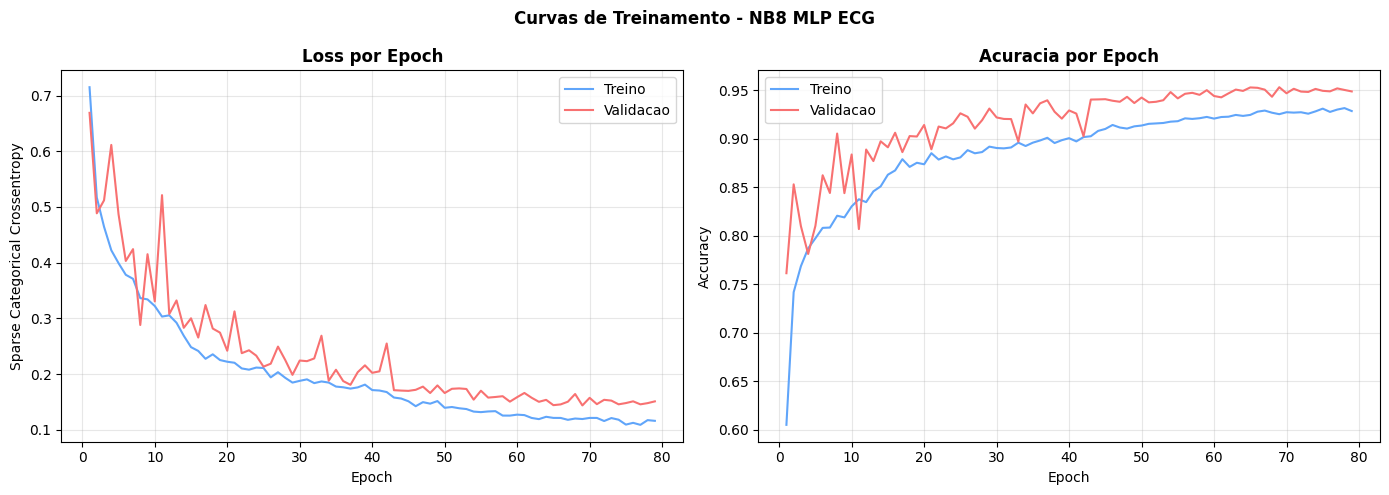

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

# Loss
axes[0].plot(epochs_range, history.history['loss'],    label='Treino',    color='#60a5fa')
axes[0].plot(epochs_range, history.history['val_loss'], label='Validacao', color='#f87171')
axes[0].set_title('Loss por Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Sparse Categorical Crossentropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history.history['accuracy'],    label='Treino',    color='#60a5fa')
axes[1].plot(epochs_range, history.history['val_accuracy'], label='Validacao', color='#f87171')
axes[1].set_title('Acuracia por Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Treinamento - NB8 MLP ECG', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## Avaliação no Conjunto de Teste

Metricas relevantes para dados desbalanceados:

- F1-score por classe: mais informativo que acuracia global

- F1 macro: media simples entre classes (penaliza classes fracas igualmente)

- F1 weighted: media ponderada pela frequencia (mais justo para deploy real)

- Confusion matrix: mostra quais classes estao sendo confundidas

### Avaliação e Classification Report

In [18]:
# Avaliacao basica
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print()

# Predicoes
y_pred_proba = model.predict(X_test_norm, verbose=0)
y_pred = y_pred_proba.argmax(axis=1)

# Classification report completo
target_names = [label_map[float(i)] for i in range(5)]
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

Test Loss: 0.1526
Test Accuracy: 0.9509 (95.09%)

=== Classification Report ===
                      precision    recall  f1-score   support

          Normal (N)     0.9934    0.9519    0.9722     18118
Supraventricular (S)     0.4815    0.8435    0.6131       556
     Ventricular (V)     0.8858    0.9427    0.9133      1448
          Fusion (F)     0.4557    0.9198    0.6094       162
    Desconhecido (Q)     0.9408    0.9876    0.9636      1608

            accuracy                         0.9509     21892
           macro avg     0.7514    0.9291    0.8143     21892
        weighted avg     0.9654    0.9509    0.9559     21892



###  Confusion Matrix

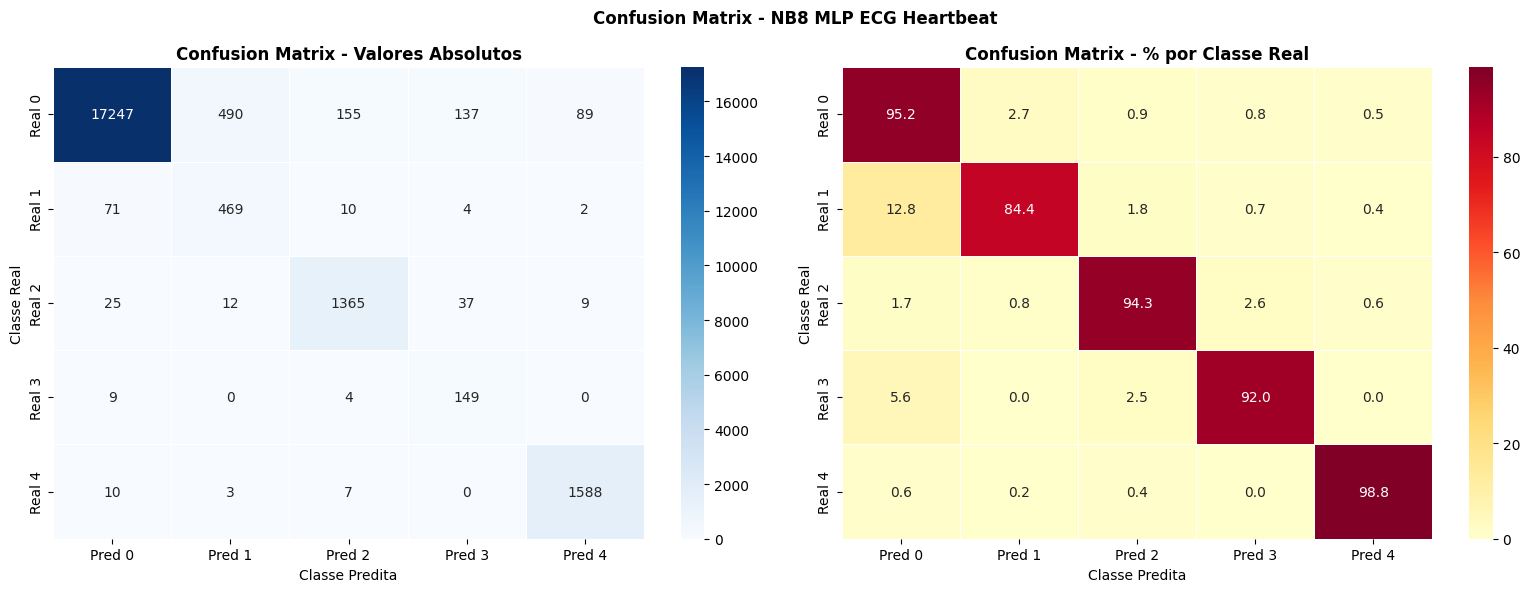

In [19]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            cmap='Blues', linewidths=0.5,
            xticklabels=[f'Pred {i}' for i in range(5)],
            yticklabels=[f'Real {i}' for i in range(5)])
axes[0].set_title('Confusion Matrix - Valores Absolutos', fontweight='bold')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

# Normalizada (% por classe real)
sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=axes[1],
            cmap='YlOrRd', linewidths=0.5,
            xticklabels=[f'Pred {i}' for i in range(5)],
            yticklabels=[f'Real {i}' for i in range(5)])
axes[1].set_title('Confusion Matrix - % por Classe Real', fontweight='bold')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

plt.suptitle('Confusion Matrix - NB8 MLP ECG Heartbeat', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

## Avaliação Binaria: Normal vs Anormal

O enunciado do Ir Alem 2 pede "classificacao binaria (normal vs. anormal)". O modelo foi treinado com 5 classes porque o dataset MIT-BIH tem 5 tipos de arritmia distintos, isso e tecnicamente mais rico e correto.

Para atender ao requisito binario SEM perder o trabalho multiclasse,
agrupamos as predicoes:
  - Classe 0 (Normal) -> "Normal"
  - Classes 1, 2, 3, 4 (qualquer arritmia) -> "Anormal"

Isso responde diretamente a pergunta clinica mais urgente: "esse batimento e normal ou precisa de atencao medica?"

=== Avaliação Binária: Normal vs Anormal ===

              precision    recall  f1-score   support

      Normal     0.9934    0.9519    0.9722     18118
     Anormal     0.8077    0.9695    0.8813      3774

    accuracy                         0.9550     21892
   macro avg     0.9006    0.9607    0.9267     21892
weighted avg     0.9614    0.9550    0.9565     21892

ROC-AUC (Normal vs Anormal): 0.9921



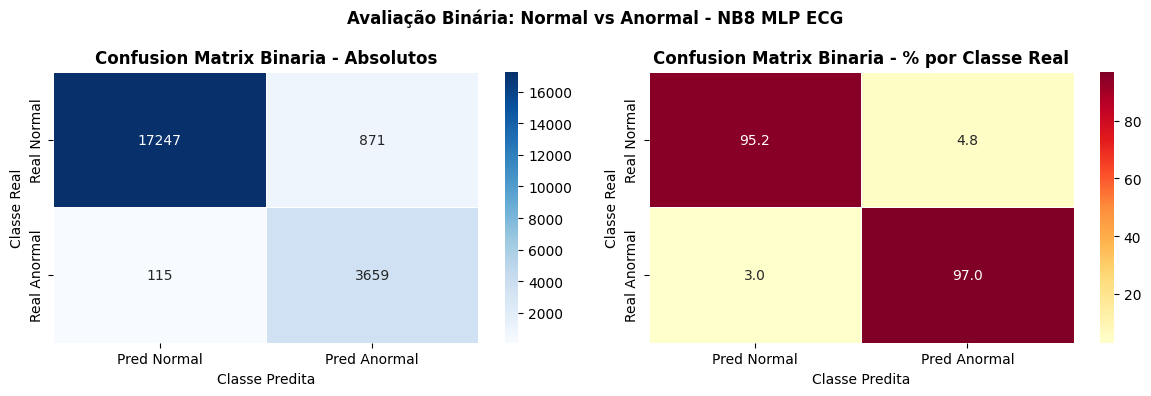

=== Metricas Clinicas (Triagem) ===
Sensibilidade (recall Anormal): 0.9695  <- capacidade de detectar arritmias
Especificidade (recall Normal): 0.9519  <- capacidade de nao alarmar falso
ROC-AUC: 0.9921

Interpretacao para deploy em wearable:
- De 3,774 batimentos anormais, o modelo detectou 3,659 (97.0%)
- De 18,118 batimentos normais, classificou 17,247 corretamente (95.2%)


In [20]:
# Agrupamento binario: Normal (0) vs. Anormal (qualquer arritmia 1-4)
y_test_bin = (y_test != 0).astype(int)   # 0=Normal, 1=Anormal
y_pred_bin = (y_pred != 0).astype(int)

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score)

print('=== Avaliação Binária: Normal vs Anormal ===')
print()
print(classification_report(
    y_test_bin, y_pred_bin,
    target_names=['Normal', 'Anormal'],
    digits=4
))

# ROC-AUC binario usando probabilidade da classe "Anormal"
# P(Anormal) = 1 - P(Normal) = soma das probabilidades das classes 1,2,3,4
p_anormal = 1.0 - y_pred_proba[:, 0]
auc = roc_auc_score(y_test_bin, p_anormal)
print(f'ROC-AUC (Normal vs Anormal): {auc:.4f}')
print()

# Confusion matrix binaria
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
cm_bin_pct = cm_bin.astype(float) / cm_bin.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_bin, annot=True, fmt='d', ax=axes[0],
            cmap='Blues', linewidths=0.5,
            xticklabels=['Pred Normal', 'Pred Anormal'],
            yticklabels=['Real Normal', 'Real Anormal'])
axes[0].set_title('Confusion Matrix Binaria - Absolutos', fontweight='bold')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

sns.heatmap(cm_bin_pct, annot=True, fmt='.1f', ax=axes[1],
            cmap='YlOrRd', linewidths=0.5,
            xticklabels=['Pred Normal', 'Pred Anormal'],
            yticklabels=['Real Normal', 'Real Anormal'])
axes[1].set_title('Confusion Matrix Binaria - % por Classe Real', fontweight='bold')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

plt.suptitle('Avaliação Binária: Normal vs Anormal - NB8 MLP ECG', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'confusion_matrix_binaria.png'), dpi=120, bbox_inches='tight')
plt.show()

# Resumo executivo binario
tn, fp, fn, tp = cm_bin.ravel()
sensibilidade = tp / (tp + fn)   # recall da classe Anormal - crucial na triagem
especificidade = tn / (tn + fp)  # recall da classe Normal

print('=== Metricas Clinicas (Triagem) ===')
print(f'Sensibilidade (recall Anormal): {sensibilidade:.4f}  <- capacidade de detectar arritmias')
print(f'Especificidade (recall Normal): {especificidade:.4f}  <- capacidade de nao alarmar falso')
print(f'ROC-AUC: {auc:.4f}')
print()
print('Interpretacao para deploy em wearable:')
print(f'- De {tp+fn:,} batimentos anormais, o modelo detectou {tp:,} ({sensibilidade*100:.1f}%)')
print(f'- De {tn+fp:,} batimentos normais, classificou {tn:,} corretamente ({especificidade*100:.1f}%)')

## Conversão para TFLite INT8

O Raspberry Pi 5 com Coral TPU requer modelo em formato INT8 para
aceleracao por hardware (4 TOPS). A quantizacao post-training INT8
usa um representative_dataset para calibrar os quantis de ativacao.

Passos:
1. Converter modelo Keras para TFLite com quantizacao INT8
2. Salvar o arquivo .tflite
3. Benchmark local de latencia (CPU - no RPi5 sera ainda mais rapido)

### Conversão TFLite

In [21]:
def representative_dataset_gen():
    for i in range(min(500, len(X_test_norm))):
        sample = X_test_norm[i:i+1].astype(np.float32)
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

print('Convertendo para TFLite INT8...')
tflite_model = converter.convert()

tflite_path = os.path.join(MODELS_DIR, 'nb8_mlp_ecg_int8.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_kb = os.path.getsize(tflite_path) / 1024
print(f'Modelo TFLite INT8 salvo: {tflite_path}')
print(f'Tamanho: {size_kb:.1f} KB')

Convertendo para TFLite INT8...
INFO:tensorflow:Assets written to: C:\Users\isaac\AppData\Local\Temp\tmpswf31vds\assets


INFO:tensorflow:Assets written to: C:\Users\isaac\AppData\Local\Temp\tmpswf31vds\assets


Saved artifact at 'C:\Users\isaac\AppData\Local\Temp\tmpswf31vds'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187), dtype=tf.float32, name='ecg_input')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2570311277008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939128208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939129552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939128400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939127824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939130512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939130704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939130896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939131664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939131856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2568939129744: T

c:\Users\isaac\Desktop\FIAP-AI-university-projects\.fiap_venv_py312\Lib\site-packages\tensorflow\lite\python\convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Modelo TFLite INT8 salvo: c:\Users\isaac\Desktop\FIAP-AI-university-projects\last_year\challenge\ai_cardiology\models\nb8_mlp_ecg_int8.tflite
Tamanho: 102.5 KB


### Benchmark de Latência

In [22]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input details: ', input_details[0]['shape'], input_details[0]['dtype'])
print('Output details:', output_details[0]['shape'], output_details[0]['dtype'])
print()

# Parametros de quantizacao do tensor de entrada (modelo INT8 full-integer)
# O modelo espera INT8: e necessario quantizar float32 -> int8 manualmente.
# Formula: int8 = round(float32 / scale) + zero_point, clipped em [-128, 127]
in_scale = input_details[0]['quantization_parameters']['scales'][0]
in_zero_pt = input_details[0]['quantization_parameters']['zero_points'][0]
out_scale = output_details[0]['quantization_parameters']['scales'][0]
out_zero_pt = output_details[0]['quantization_parameters']['zero_points'][0]

def quantize_input(x_f32):
    x_q = np.round(x_f32 / in_scale + in_zero_pt).astype(np.int8)
    return x_q

def dequantize_output(x_int8):
    return (x_int8.astype(np.float32) - out_zero_pt) * out_scale

N_BENCH = 1000
t0 = time.perf_counter()
for i in range(N_BENCH):
    idx = i % len(X_test_norm)
    sample = quantize_input(X_test_norm[idx:idx+1].astype(np.float32))
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    _ = dequantize_output(interpreter.get_tensor(output_details[0]['index']))

elapsed_ms = (time.perf_counter() - t0) / N_BENCH * 1000
print(f'Benchmark: {N_BENCH} inferencias')
print(f'Latencia media (CPU local): {elapsed_ms:.3f} ms por batimento')
print(f'Throughput estimado: {1000/elapsed_ms:.0f} batimentos/segundo')
print()
print('Nota: no Coral TPU (4 TOPS) a latencia sera ainda menor.')
print('Requisito do projeto: <1ms por batimento a 360Hz.')

Input details:  [  1 187] <class 'numpy.int8'>
Output details: [1 5] <class 'numpy.int8'>

Benchmark: 1000 inferencias
Latencia media (CPU local): 0.036 ms por batimento
Throughput estimado: 27644 batimentos/segundo

Nota: no Coral TPU (4 TOPS) a latencia sera ainda menor.
Requisito do projeto: <1ms por batimento a 360Hz.


## MLOps - Registro de Experimento e Model Card

> Salvar os metadados do experimento para rastreabilidade e comparacao com versoes futuras do modelo (NB9, ensemble, etc.)

### Experiment Log


In [23]:
from sklearn.metrics import f1_score

f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

experiment_log = {
    'notebook': 'NB8',
    'dataset': 'MIT-BIH Arrhythmia (shayanfazeli/heartbeat)',
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'n_features': 187,
    'n_classes': 5,
    'class_labels': label_map,
    'architecture': 'MLP-256-128-64-5',
    'total_params': int(model.count_params()),
    'optimizer': 'Adam lr=1e-3',
    'class_weight': 'balanced',
    'normalization': 'global [0,1] + per-sample Z-score',
    'batch_size': 64,
    'epochs_trained': len(history.history['loss']),
    'best_val_accuracy': round(float(max(history.history['val_accuracy'])), 4),
    'test_accuracy': round(float(test_acc), 4),
    'test_f1_macro': round(float(f1_macro), 4),
    'test_f1_weighted': round(float(f1_weighted), 4),
    'tflite_size_kb': round(size_kb, 1),
    'latency_ms_cpu': round(elapsed_ms, 3),
}

log_path = os.path.join(LOGS_DIR, 'experiment_log_nb8.json')
with open(log_path, 'w') as f:
    json.dump(experiment_log, f, indent=2, ensure_ascii=False)

print('Experiment log salvo em:', rel(log_path))
print(json.dumps(experiment_log, indent=2, ensure_ascii=False))

Experiment log salvo em: logs\experiment_log_nb8.json
{
  "notebook": "NB8",
  "dataset": "MIT-BIH Arrhythmia (shayanfazeli/heartbeat)",
  "n_train": 87554,
  "n_test": 21892,
  "n_features": 187,
  "n_classes": 5,
  "class_labels": {
    "0.0": "Normal (N)",
    "1.0": "Supraventricular (S)",
    "2.0": "Ventricular (V)",
    "3.0": "Fusion (F)",
    "4.0": "Desconhecido (Q)"
  },
  "architecture": "MLP-256-128-64-5",
  "total_params": 91397,
  "optimizer": "Adam lr=1e-3",
  "class_weight": "balanced",
  "normalization": "global [0,1] + per-sample Z-score",
  "batch_size": 64,
  "epochs_trained": 79,
  "best_val_accuracy": 0.9529,
  "test_accuracy": 0.9509,
  "test_f1_macro": 0.8143,
  "test_f1_weighted": 0.9559,
  "tflite_size_kb": 102.5,
  "latency_ms_cpu": 0.036
}


### Model Card

In [24]:
report_str = classification_report(y_test, y_pred, target_names=target_names, digits=4)

model_card = f"""# Model Card - NB8 MLP ECG Heartbeat Classifier

## Descricao

Rede MLP para classificacao de arritmias cardiacas em batimentos ECG segmentados.
Treinada no dataset MIT-BIH Arrhythmia (Kaggle: shayanfazeli/heartbeat).

## Tarefa

Classificacao multiclasse (5 classes) a partir de 187 pontos de sinal ECG.

## Dataset

- Fonte: MIT-BIH Arrhythmia Database, re-processado por Shayan Fazeli
- Treino: {len(X_train):,} amostras | Teste: {len(X_test):,} amostras
- Features: 187 pontos de sinal ECG a 360 Hz (~0.52s por batimento)
- Normalizacao: min-max global [0,1] na criacao + Z-score por amostra

## Classes

| ID | Nome                | Treino | Teste |
|----|---------------------|--------|-------|
|  0 | Normal (N)          | 72.471 | 18.118 |
|  1 | Supraventricular (S)|  2.223 |    556 |
|  2 | Ventricular (V)     |  5.788 |  1.448 |
|  3 | Fusion (F)          |    641 |    162 |
|  4 | Desconhecido (Q)    |  6.431 |  1.608 |

## Arquitetura

MLP: Input(187) -> Dense(256,BN,DR0.30) -> Dense(128,BN,DR0.25) -> Dense(64,BN,DR0.20) -> Dense(5,softmax)
Parametros totais: ~{int(model.count_params()):,}

## Metricas no Conjunto de Teste

- Acuracia: {test_acc:.4f}
- F1 Macro: {f1_macro:.4f}
- F1 Weighted: {f1_weighted:.4f}

~~~
{report_str}
~~~

## Latencia

- TFLite INT8: {size_kb:.1f} KB
- Latencia CPU (local): {elapsed_ms:.3f} ms/batimento
- Alvo Coral TPU: <1ms

## Limitacoes

- Treinado em 1 derivacao (MLII do MIT-BIH) - pode nao generalizar para outras derivacoes
- Dataset dos anos 90 com equipamento especifico - variabilidade real pode ser maior
- NAO deve ser usado como diagnostico clinico definitivo - apenas triagem automatizada

## Uso Pretendido

Triagem de arritmias em wearable cardiaco (Wearable XIAO nRF52840 + ADS1293),
rodando no Coral TPU acoplado ao Raspberry Pi 5 (Hub do projeto Cardio-Edge-AI).
"""

card_path = os.path.join(LOGS_DIR, 'model_card_nb8.md')
with open(card_path, 'w', encoding='utf-8') as f:
    f.write(model_card)

print('Model Card salvo em:', rel(card_path))

Model Card salvo em: logs\model_card_nb8.md


### Verificação Final dos Artefatos

In [25]:
print('=== Artefatos Gerados - NB8 ===')
artefatos = [
    os.path.join(MODELS_DIR, 'nb8_mlp_ecg_best.keras'),
    os.path.join(MODELS_DIR, 'nb8_mlp_ecg_int8.tflite'),
    os.path.join(LOGS_DIR, 'experiment_log_nb8.json'),
    os.path.join(LOGS_DIR, 'model_card_nb8.md'),
    os.path.join(LOGS_DIR, 'class_distribution.png'),
    os.path.join(LOGS_DIR, 'signal_morphology.png'),
    os.path.join(LOGS_DIR, 'signal_mean_envelope.png'),
    os.path.join(LOGS_DIR, 'training_curves.png'),
    os.path.join(LOGS_DIR, 'confusion_matrix.png'),
]

for path in artefatos:
    exists = os.path.exists(path)
    size = os.path.getsize(path) / 1024 if exists else 0
    status = 'OK' if exists else 'FALTANDO'
    print(f'  [{status}] {rel(path):<45} {size:.1f} KB')

=== Artefatos Gerados - NB8 ===
  [OK] models\nb8_mlp_ecg_best.keras                 1121.4 KB
  [OK] models\nb8_mlp_ecg_int8.tflite                102.5 KB
  [OK] logs\experiment_log_nb8.json                  0.7 KB
  [OK] logs\model_card_nb8.md                        2.3 KB
  [OK] logs\class_distribution.png                   57.0 KB
  [OK] logs\signal_morphology.png                    191.4 KB
  [OK] logs\signal_mean_envelope.png                 160.8 KB
  [OK] logs\training_curves.png                      102.6 KB
  [OK] logs\confusion_matrix.png                     79.0 KB
